# 4. Analyze and Summarize 1910 Clusters

Inputs
- 1910_clusters.json
- 1910_embeddings.txt
- 1910_embeddings.npy
- 1910_photos/

Outputs
- 1910_cluster_stats.json (sizes, representative examples)
- 1910_cluster_concepts.json (top zero-shot concepts per cluster)
- 1910_cluster_top1_concept.json (top-1 zero-shot concept per cluster)


This notebook computes cluster statistics, selects representative images per cluster (centroid-nearest), and performs CLIP-style zero-shot concept labeling using the same model that produced our embeddings:
`SentenceTransformer("clip-ViT-B-32")` (512-D).

## Setup

In [1]:
from pathlib import Path
import json
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import ipywidgets as widgets
from IPython.display import display, clear_output

from sentence_transformers import SentenceTransformer

/opt/anaconda3/lib/python3.11/site-packages/sentence_transformers/cross_encoder/CrossEncoder.py:11: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm, trange


In [2]:
# Paths
CLUSTERS_JSON = Path("1910_clusters.json")
EMB_TXT = Path("1910_embeddings.txt")
EMB_NPY = Path("1910_embeddings.npy")
PHOTOS_DIR = Path("1910_photos")
print("Using PHOTOS_DIR:", PHOTOS_DIR)

# Load clusters
clusters = json.loads(CLUSTERS_JSON.read_text(encoding="utf-8"))

# filenames and embeddings
filenames_1910 = [ln.strip() for ln in EMB_TXT.read_text(encoding="utf-8").splitlines() if ln.strip()]
embeddings_1910 = np.load(EMB_NPY)

print("Loaded clusters:", len(clusters))
print("filenames:", len(filenames_1910))
print("embeddings:", embeddings_1910.shape)

# Alignment check
if embeddings_1910.ndim != 2:
    raise ValueError(f"Expected 2D embedding matrix, got shape={embeddings_1910.shape}")

if len(filenames_1910) != embeddings_1910.shape[0]:
    raise ValueError(
        f"Row mismatch: {len(filenames_1910)} filenames vs {embeddings_1910.shape[0]} embedding rows"
    )

print("Alignment check passed.")

Using PHOTOS_DIR: 1910_photos
Loaded clusters: 2321
filenames: 72062
embeddings: (72062, 512)
Alignment check passed.


## Helpers

In [3]:
# Usual helpers
def jpg_exists(rel_jpg: str) -> bool:
    return (PHOTOS_DIR / rel_jpg).exists()

def open_image(rel_jpg: str) -> Image.Image:
    p = PHOTOS_DIR / rel_jpg
    if not p.exists():
        raise FileNotFoundError(f"Missing image: {p}")
    return Image.open(p).convert("RGB")

def show_image_grid(rel_jpgs, title="", cols=6, figsize_per_cell=2.0, max_images=60):
    rel_jpgs = list(rel_jpgs)[:max_images]
    n = len(rel_jpgs)
    if n == 0:
        print("No images to display.")
        return

    rows = (n + cols - 1) // cols
    plt.figure(figsize=(cols * figsize_per_cell, rows * figsize_per_cell))
    for j, rel in enumerate(rel_jpgs):
        ax = plt.subplot(rows, cols, j + 1)
        try:
            img = open_image(rel)
            ax.imshow(img)
            ax.set_title(f"{j}", fontsize=8)
        except Exception:
            ax.text(0.5, 0.5, "ERR", ha="center", va="center")
        ax.axis("off")

    if title:
        plt.suptitle(title)
    plt.show()

## Build lookup maps

In [4]:
# Build lookup maps (filename <-> index, and rel_jpg -> index)
idx_to_name = filenames_1910
name_to_idx = {name: i for i, name in enumerate(idx_to_name) if name not in idx_to_name[:i]}

def filename_to_reljpg(name: str) -> str:
    stem = str(Path(name))
    return f"{stem}.jpg"

reljpg_to_idx = {filename_to_reljpg(name): i for i, name in enumerate(filenames_1910)}

# rel_jpg -> cluster_id + duplicate check
jpg_to_cluster = {}
dupes = {}

for cid, jpg_list in clusters.items():
    for jpg in jpg_list:
        if jpg in jpg_to_cluster:
            dupes.setdefault(jpg, [jpg_to_cluster[jpg]]).append(cid)
        jpg_to_cluster[jpg] = cid

print("reljpg_to_idx entries:", len(reljpg_to_idx))
print("jpg_to_cluster entries:", len(jpg_to_cluster))

if dupes:
    print(f"{len(dupes)} images appear in more than one cluster. Showing first 10:")
    for jpg, cids in list(dupes.items())[:10]:
        print(" ", jpg, "->", cids)
else:
    print("No duplicate images across clusters.")


reljpg_to_idx entries: 72062
jpg_to_cluster entries: 6121
No duplicate images across clusters.


## Cluster statistics table + distribution plot

,cluster_id,size
0,84,106
1,88,62
2,4,62
3,39,57
4,125,41
5,89,32
6,90,32
7,94,32
8,134,28
9,561,21


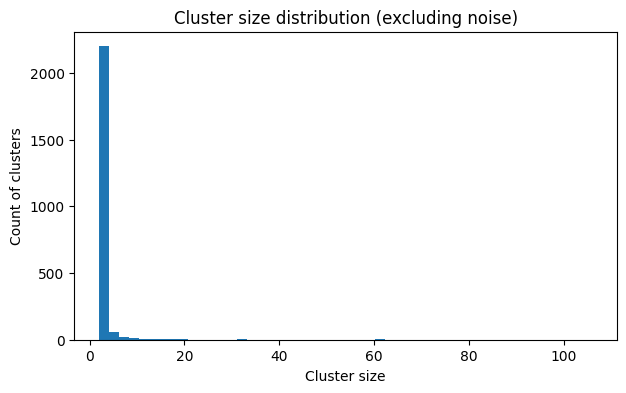

Total clusters: 2321
Total images in clusters: 6121


In [5]:
rows = []
for cid, rels in clusters.items():
    size = len(rels)
    rows.append({"cluster_id": cid, "size": size})

stats_df = pd.DataFrame(rows).sort_values("size", ascending=False).reset_index(drop=True)
display(stats_df.head(30))

plt.figure(figsize=(7,4))
plt.hist(stats_df["size"].values, bins=50)
plt.title("Cluster size distribution (excluding noise)")
plt.xlabel("Cluster size")
plt.ylabel("Count of clusters")
plt.show()

print("Total clusters:", len(stats_df))
print("Total images in clusters:", int(stats_df["size"].sum()))


## One Representative image per cluster (centroid-nearest)

Picking image with embeddings closest to the cluster mean

Top cluster: 84 | reps: 5


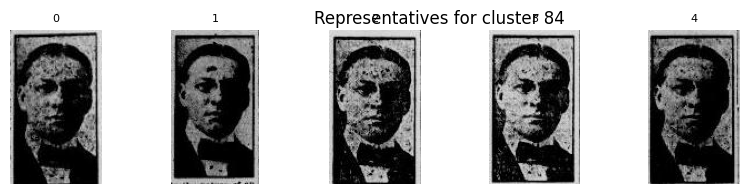

In [6]:
def representative_reljpgs(cid: str, k):
    rels_work = clusters[cid]
    if not rels_work:
        return []

    idxs = [reljpg_to_idx[r] for r in rels_work if r in reljpg_to_idx]
    if not idxs:
        return []

    X = embeddings_1910[idxs]   # (m = cluster size, D)
    center = X.mean(axis=0)  # (D,)
    d = np.linalg.norm(X - center, axis=1)
    top = np.argsort(d)[:min(k, len(idxs))]

    return [rels_work[int(t)] for t in top]

# Preview representatives for the largest cluster
top_cid = stats_df.loc[0, "cluster_id"]
reps = representative_reljpgs(top_cid, k=5)
print("Top cluster:", top_cid, "| reps:", len(reps))
show_image_grid(reps, title=f"Representatives for cluster {top_cid}", cols=6, max_images=24)

In [7]:
cluster_stats = {}

for _, row in stats_df.iterrows():
    cid = row["cluster_id"]
    cluster_stats[cid] = {
        "size": int(row["size"]),
        "representatives": representative_reljpgs(cid, k=3),
    }

out_stats = Path("1910_cluster_stats.json")
out_stats.write_text(json.dumps(cluster_stats, ensure_ascii=False, indent=2), encoding="utf-8")
print("Saved:", out_stats)

Saved: 1910_cluster_stats.json


## Zero-shot concept labeling

In [8]:
print("Loading model: sentence-transformers/clip-ViT-B-32")
clip_model = SentenceTransformer("clip-ViT-B-32")

print("Text embedding dim:", clip_model.get_sentence_embedding_dimension())
print("Image embedding dim:", embeddings_1910.shape[1])

Loading model: sentence-transformers/clip-ViT-B-32
Text embedding dim: None
Image embedding dim: 512


In [28]:
# Concept prompts
LABELS = [
    "portrait",
    "group of people",
    "sports athlete",
    "building",
    "landscape",
    "landmark",
    "map",
    "marketing advertisement",
    "transportation vehicle",
    "animal",
    "object"
]

PROMPTS = [f"{lab}" for lab in LABELS] # experiment w/o this (label only)
print("Number of labels:", len(LABELS))
print("Example prompts:", PROMPTS[:3])

Number of labels: 11
Example prompts: ['portrait', 'group of people', 'sports athlete']


In [29]:
# Embed prompts and normalize for cosine similarity
text_vecs = clip_model.encode( # SentenceTransformers API
    PROMPTS,
    convert_to_numpy=True,
    normalize_embeddings=True
)

print("text_vecs shape:", text_vecs.shape)  

text_vecs shape: (11, 512)


### If top label score does not exceed 0.23, assign to "Other" category

In [30]:
# Normalize image embeddings for cosine similarity
img_vecs = embeddings_1910 / np.linalg.norm(embeddings_1910, axis=1, keepdims=True)

THRESH = 0.23

def top_concepts_for_cluster(cid, topk=3, thresh=THRESH):
    cid = str(cid)
    rels = clusters.get(cid, [])
    if not rels:
        return []

    idxs = [reljpg_to_idx[r] for r in rels if r in reljpg_to_idx]
    if not idxs:
        return []

    X = img_vecs[idxs]
    sims = X @ text_vecs.T
    mean_scores = sims.mean(axis=0)

    best = np.argsort(mean_scores)[::-1][:topk]
    results = [{"label": LABELS[i], "score": float(mean_scores[i])} for i in best]

    if results[0]["score"] < thresh:
        return [{"label": "Other", "score": float(results[0]["score"])}]

    return results

for cid in stats_df["cluster_id"].head(5):
    print("Cluster", cid, "top concepts:", top_concepts_for_cluster(cid))

Cluster 84 top concepts: [{'label': 'portrait', 'score': 0.24122492969036102}, {'label': 'marketing advertisement', 'score': 0.21685060858726501}, {'label': 'object', 'score': 0.20902709662914276}]
Cluster 88 top concepts: [{'label': 'portrait', 'score': 0.2505626082420349}, {'label': 'marketing advertisement', 'score': 0.21688920259475708}, {'label': 'group of people', 'score': 0.2121472805738449}]
Cluster 4 top concepts: [{'label': 'landscape', 'score': 0.2554595172405243}, {'label': 'object', 'score': 0.23993320763111115}, {'label': 'portrait', 'score': 0.23491153120994568}]
Cluster 39 top concepts: [{'label': 'portrait', 'score': 0.2540128529071808}, {'label': 'marketing advertisement', 'score': 0.22215139865875244}, {'label': 'group of people', 'score': 0.2137402445077896}]
Cluster 125 top concepts: [{'label': 'portrait', 'score': 0.24682973325252533}, {'label': 'marketing advertisement', 'score': 0.2237575352191925}, {'label': 'group of people', 'score': 0.21452657878398895}]


In [31]:
# Save 1910_cluster_concepts.json
cluster_concepts = {}
for cid in clusters.keys():
    cluster_concepts[cid] = {
        "top_concepts": top_concepts_for_cluster(cid, topk=3)
    }

out_concepts = Path("1910_cluster_concepts.json")
out_concepts.write_text(json.dumps(cluster_concepts, ensure_ascii=False, indent=2), encoding="utf-8")
print("Saved:", out_concepts)

Saved: 1910_cluster_concepts.json


Cluster: 84
Top concepts:
  portrait (0.241)
  marketing advertisement (0.217)
  object (0.209)


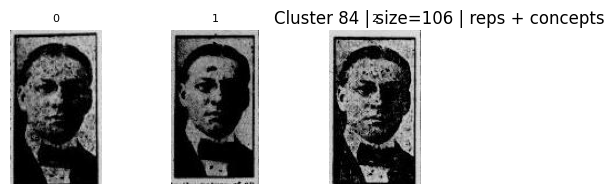

Cluster: 88
Top concepts:
  portrait (0.251)
  marketing advertisement (0.217)
  group of people (0.212)


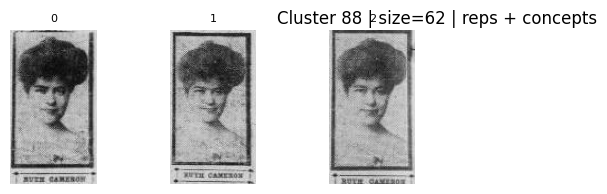

Cluster: 4
Top concepts:
  landscape (0.255)
  object (0.240)
  portrait (0.235)


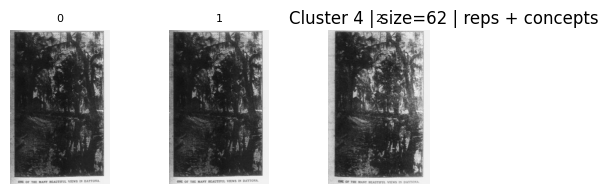

Cluster: 39
Top concepts:
  portrait (0.254)
  marketing advertisement (0.222)
  group of people (0.214)


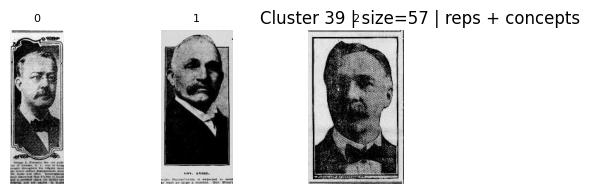

Cluster: 125
Top concepts:
  portrait (0.247)
  marketing advertisement (0.224)
  group of people (0.215)


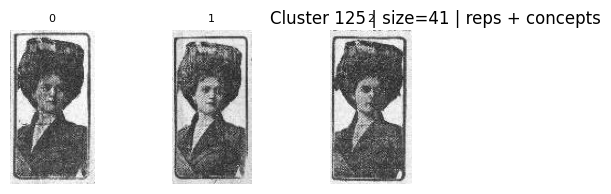

In [32]:
top5 = stats_df["cluster_id"].head(5).tolist()

for cid in top5:
    cid = str(cid)  
    
    reps = cluster_stats[cid]["representatives"]
    concepts = cluster_concepts[cid]["top_concepts"]

    print("=" * 80)
    print("Cluster:", cid)
    print("Top concepts:")
    for c in concepts:
        print(" ", c["label"], f"({c['score']:.3f})")

    show_image_grid(
        reps,
        title=f"Cluster {cid} | size={cluster_stats[cid]['size']} | reps + concepts",
        cols=6,
        max_images=24
    )

Cluster: 314
Size: 3


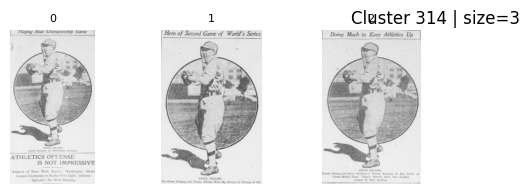

In [33]:
CLUSTER_ID = "314"
cid = str(CLUSTER_ID)

all_rels = clusters[cid]   

print("Cluster:", cid)
print("Size:", len(all_rels))

show_image_grid(
    all_rels,
    title=f"Cluster {cid} | size={len(all_rels)}",
    cols=6,
    max_images=len(all_rels)  
)

In [34]:
def top1_concept(cid: str, thresh=THRESH):
    rels = clusters.get(cid, [])
    if not rels:
        return {"label": "Other", "score": None}

    idxs = [reljpg_to_idx[r] for r in rels if r in reljpg_to_idx]
    if not idxs:
        return {"label": "Other", "score": None}

    X = img_vecs[idxs]          
    sims = X @ text_vecs.T     
    mean_scores = sims.mean(axis=0)

    best_i = int(np.argmax(mean_scores))
    best_score = float(mean_scores[best_i])

    if best_score < thresh:
        return {
            "label": "Other",
            "score": best_score,
        }

    return {
        "label": LABELS[best_i],
        "score": best_score,
    }

cluster_top1 = {}
for cid in clusters.keys():
    cluster_top1[cid] = top1_concept(cid)

print("Clusters labeled:", len(cluster_top1), "out of", len(clusters))

Clusters labeled: 2321 out of 2321


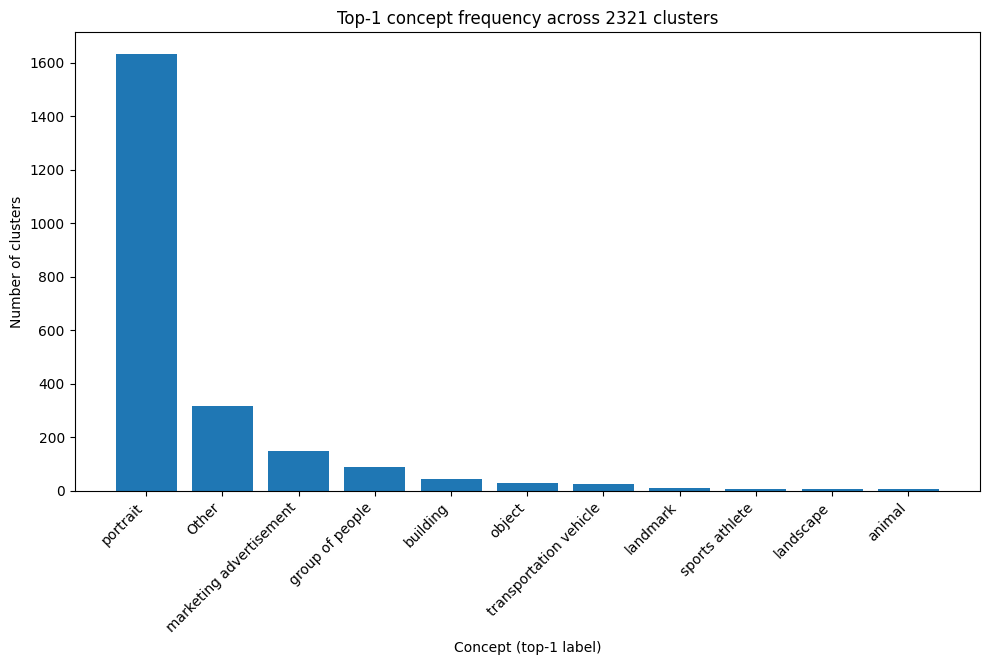

In [35]:
from collections import Counter

# Count concept assignments
counts = Counter(v["label"] for v in cluster_top1.values())

# Sort by count (descending)
labels_sorted = [k for k, _ in counts.most_common()]
values_sorted = [counts[k] for k in labels_sorted]

plt.figure(figsize=(10, 4 + 0.25 * len(labels_sorted)))
plt.bar(labels_sorted, values_sorted)
plt.title("Top-1 concept frequency across 2321 clusters")
plt.xlabel("Concept (top-1 label)")
plt.ylabel("Number of clusters")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [36]:
Path("1910_cluster_top1_concept.json").write_text(
    json.dumps(cluster_top1, ensure_ascii=False, indent=2),
    encoding="utf-8"
)
print("Saved: 1910_cluster_top1_concept.json")


Saved: 1910_cluster_top1_concept.json


In [ ]:
rows = []
for cid, info in cluster_top1.items():
    label = info["label"]
    n_images = len(clusters.get(cid, []))
    rows.append({"cid": cid, "category label": label, "n_images": n_images})

df_totals = pd.DataFrame(rows)

total_clusters = len(df_totals)
total_images = df_totals["n_images"].sum()

summary = (
    df_totals.groupby("category label", as_index=False)
        .agg(
            n_clusters=("cid", "count"),
            total_images=("n_images", "sum")
        )
)

summary["% of clusters with this top1 category"] = summary["n_clusters"] / total_clusters * 100
summary["% of total images"] = summary["total_images"] / total_images * 100

summary = summary[[
    "category label",
    "n_clusters",
    "% of clusters with this top1 category",
    "total_images",
    "% of total images"
]].rename(columns={
    "n_clusters": "# clusters",
    "total_images": "# total images summed from those clusters"
}).sort_values(
    by="% of clusters with this top1 category", ascending=False
).reset_index(drop=True)

summary_display = summary.copy()
summary_display["% of clusters with this top1 category"] = summary_display["% of clusters with this top1 category"].round(2)
summary_display["% of total images"] = summary_display["% of total images"].round(2)

summary_display

,category label,# clusters,% of clusters with this top1 category,# total images summed from those clusters,% of total images
0,portrait,1632,70.31,4358,71.20
1,Other,318,13.70,733,11.98
2,marketing advertisement,149,6.42,383,6.26
3,group of people,88,3.79,211,3.45
4,building,44,1.90,141,2.30
5,object,29,1.25,70,1.14
6,transportation vehicle,27,1.16,62,1.01
7,landmark,12,0.52,31,0.51
8,sports athlete,8,0.34,17,0.28
9,animal,7,0.30,33,0.54


In [48]:
rows = []
for cid, idxs in clusters.items():
    rows.append({
        "cluster_id": cid,
        "category": top1_concept(cid),
        "cluster_size": len(idxs)
    })
pd.set_option("display.max_colwidth", None) 
df = pd.DataFrame(rows)

# sort by size
df_sorted = df.sort_values("cluster_size", ascending=False)

display(df_sorted.head())

df_sorted["category_label"] = df_sorted["category"].apply(
    lambda d: d.get("label") if isinstance(d, dict) else d
)

df_sorted.groupby("category_label")["cluster_id"].count().sort_values(ascending=False)

,cluster_id,category,cluster_size
84,84,"{'label': 'portrait', 'score': 0.24122492969036102}",106
88,88,"{'label': 'portrait', 'score': 0.2505626082420349}",62
4,4,"{'label': 'landscape', 'score': 0.2554595172405243}",62
39,39,"{'label': 'portrait', 'score': 0.2540128529071808}",57
125,125,"{'label': 'portrait', 'score': 0.24682973325252533}",41


category_label
portrait                   1632
Other                       318
marketing advertisement     149
group of people              88
building                     44
object                       29
transportation vehicle       27
landmark                     12
sports athlete                8
animal                        7
landscape                     7
Name: cluster_id, dtype: int64

## Interactive Visualizer

In [49]:
df_sorted["category_label"] = df_sorted["category"].apply(lambda d: d.get("label") if isinstance(d, dict) else d)
df_sorted["category_score"] = df_sorted["category"].apply(lambda d: d.get("score") if isinstance(d, dict) else None)

CLUSTER_STATS_PATH = Path("1910_cluster_stats.json")  
IMAGE_ROOT = Path("1910_photos")    

with open(CLUSTER_STATS_PATH, "r") as f:
    cluster_stats = json.load(f)

stats_rows = []
for cid_str, info in cluster_stats.items():
    reps = info.get("representatives", [])
    stats_rows.append({
        "cluster_id": int(cid_str),
        "cluster_size_json": info.get("size"),
        "rep_filename": reps[0] if reps else None
    })
stats_df = pd.DataFrame(stats_rows)

df_view = df_sorted.copy()
df_view["cluster_id"] = df_view["cluster_id"].astype(int)

merged = df_view.merge(stats_df, on="cluster_id", how="left")
if "cluster_size" not in merged.columns:
    merged["cluster_size"] = merged["cluster_size_json"]

def resolve_image_path(filename: str) -> Path | None:
    if not filename:
        return None
    
    p = IMAGE_ROOT / filename
    if p.exists():
        return p
    if not filename.lower().endswith(".jpg"):
        p2 = IMAGE_ROOT / (filename + ".jpg")
        if p2.exists():
            return p2
    return None

def show_grid(rows: pd.DataFrame, cols=4, max_px=220):
    """Display representative images in a grid with captions."""
    if rows.empty:
        display("No clusters found for this selection.")
        return

    for start in range(0, len(rows), cols):
        row_chunk = rows.iloc[start:start+cols]
        box = []
        for _, r in row_chunk.iterrows():
            img_path = resolve_image_path(r["rep_filename"])
            caption = f"cluster {r['cluster_id']} | size {r.get('cluster_size', 'NA')} | score {r.get('category_score', 'NA')}"
            out = widgets.Output(layout=widgets.Layout(border="1px solid #ddd", padding="6px", width="260px"))
            with out:
                if img_path and img_path.exists():
                    im = Image.open(img_path).convert("RGB")
                    w, h = im.size
                    scale = min(max_px / w, max_px / h, 1.0)
                    im = im.resize((int(w*scale), int(h*scale)))
                    display(im)
                else:
                    print("Image not found:")
                    print(r["rep_filename"])
                print(caption)
            box.append(out)
        display(widgets.HBox(box))

categories = sorted([c for c in merged["category_label"].dropna().unique().tolist()])
cat_dd = widgets.Dropdown(options=categories, description="Category:", layout=widgets.Layout(width="400px"))

n_slider = widgets.IntSlider(value=12, min=1, max=60, step=1, description="N:", continuous_update=False)
cols_slider = widgets.IntSlider(value=4, min=1, max=8, step=1, description="Cols:", continuous_update=False)

sort_dd = widgets.Dropdown(
    options=[("cluster_size (desc)", "cluster_size"), ("category_score (desc)", "category_score"), ("cluster_id (asc)", "cluster_id")],
    value="cluster_size",
    description="Sort:",
    layout=widgets.Layout(width="400px")
)

out = widgets.Output()

def render(*_):
    with out:
        clear_output(wait=True)

        cat = cat_dd.value
        N = n_slider.value
        sort_key = sort_dd.value
        cols = cols_slider.value

        sub = merged[merged["category_label"] == cat].copy()

        if sort_key in ["cluster_size", "category_score"]:
            sub = sub.sort_values(sort_key, ascending=False, na_position="last")
        else:
            sub = sub.sort_values(sort_key, ascending=True, na_position="last")

        sub = sub.head(N)

        display(sub[["cluster_id", "category_label", "category_score", "cluster_size", "rep_filename"]].reset_index(drop=True))

        show_grid(sub, cols=cols)

cat_dd.observe(render, names="value")
n_slider.observe(render, names="value")
cols_slider.observe(render, names="value")
sort_dd.observe(render, names="value")

ui = widgets.VBox([
    widgets.HBox([cat_dd, sort_dd]),
    widgets.HBox([n_slider, cols_slider]),
    out
])

display(ui)
render()

## Gantt Chart: Date ranges of clusters

In [55]:
import re
from datetime import datetime

date_1910 = re.compile(r"(1910)(\d{2})(\d{2})")

def extract_date(fname: str):
    m = date_1910.search(fname)
    if not m:
        return None

    year, month, day = m.groups()
    return datetime(
        year=int(year),
        month=int(month),
        day=int(day)
    )

In [56]:
rows = []

for cid, files in clusters.items():
    dates = [extract_date(f) for f in files]
    dates = [d for d in dates if d is not None]
    if not dates:
        continue

    rows.append({
        "cluster_id": cid,
        "n_images": len(dates),
        "start_date": min(dates),
        "end_date": max(dates),
        "span_days": (max(dates) - min(dates)).days,
    })

cluster_dates_df = pd.DataFrame(rows)
cluster_dates_df.head()


,cluster_id,n_images,start_date,end_date,span_days
0,0,2,1910-05-14,1910-05-14,0
1,1,2,1910-06-19,1910-08-17,59
2,2,2,1910-05-10,1910-05-10,0
3,3,2,1910-02-26,1910-03-24,26
4,4,62,1910-01-08,1910-02-25,48


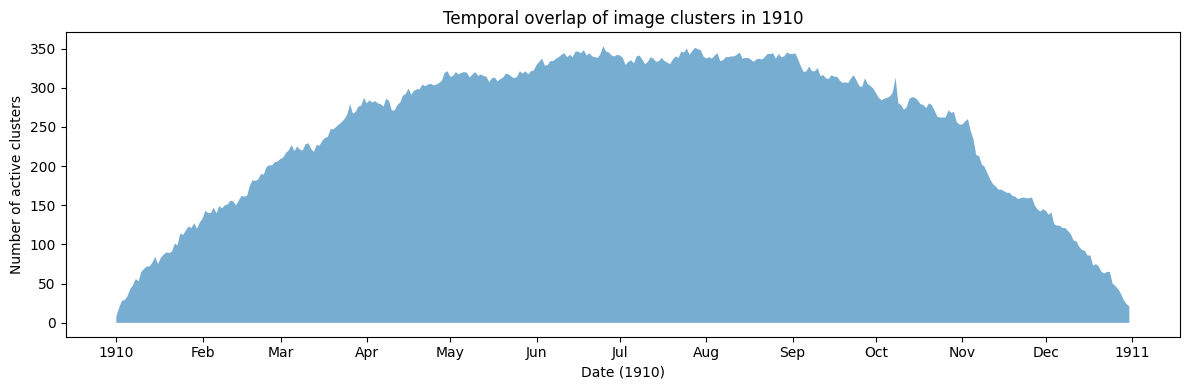

In [59]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

date_index = pd.date_range("1910-01-01", "1910-12-31", freq="D")
coverage = pd.Series(0, index=date_index)

for _, row in cluster_dates_df.iterrows():
    coverage.loc[row["start_date"] : row["end_date"]] += 1

plt.figure(figsize=(12, 4))
plt.fill_between(coverage.index, coverage.values, alpha=0.6)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))

plt.xlabel("Date (1910)")
plt.ylabel("Number of active clusters")
plt.title("Temporal overlap of image clusters in 1910")
plt.tight_layout()
plt.show()


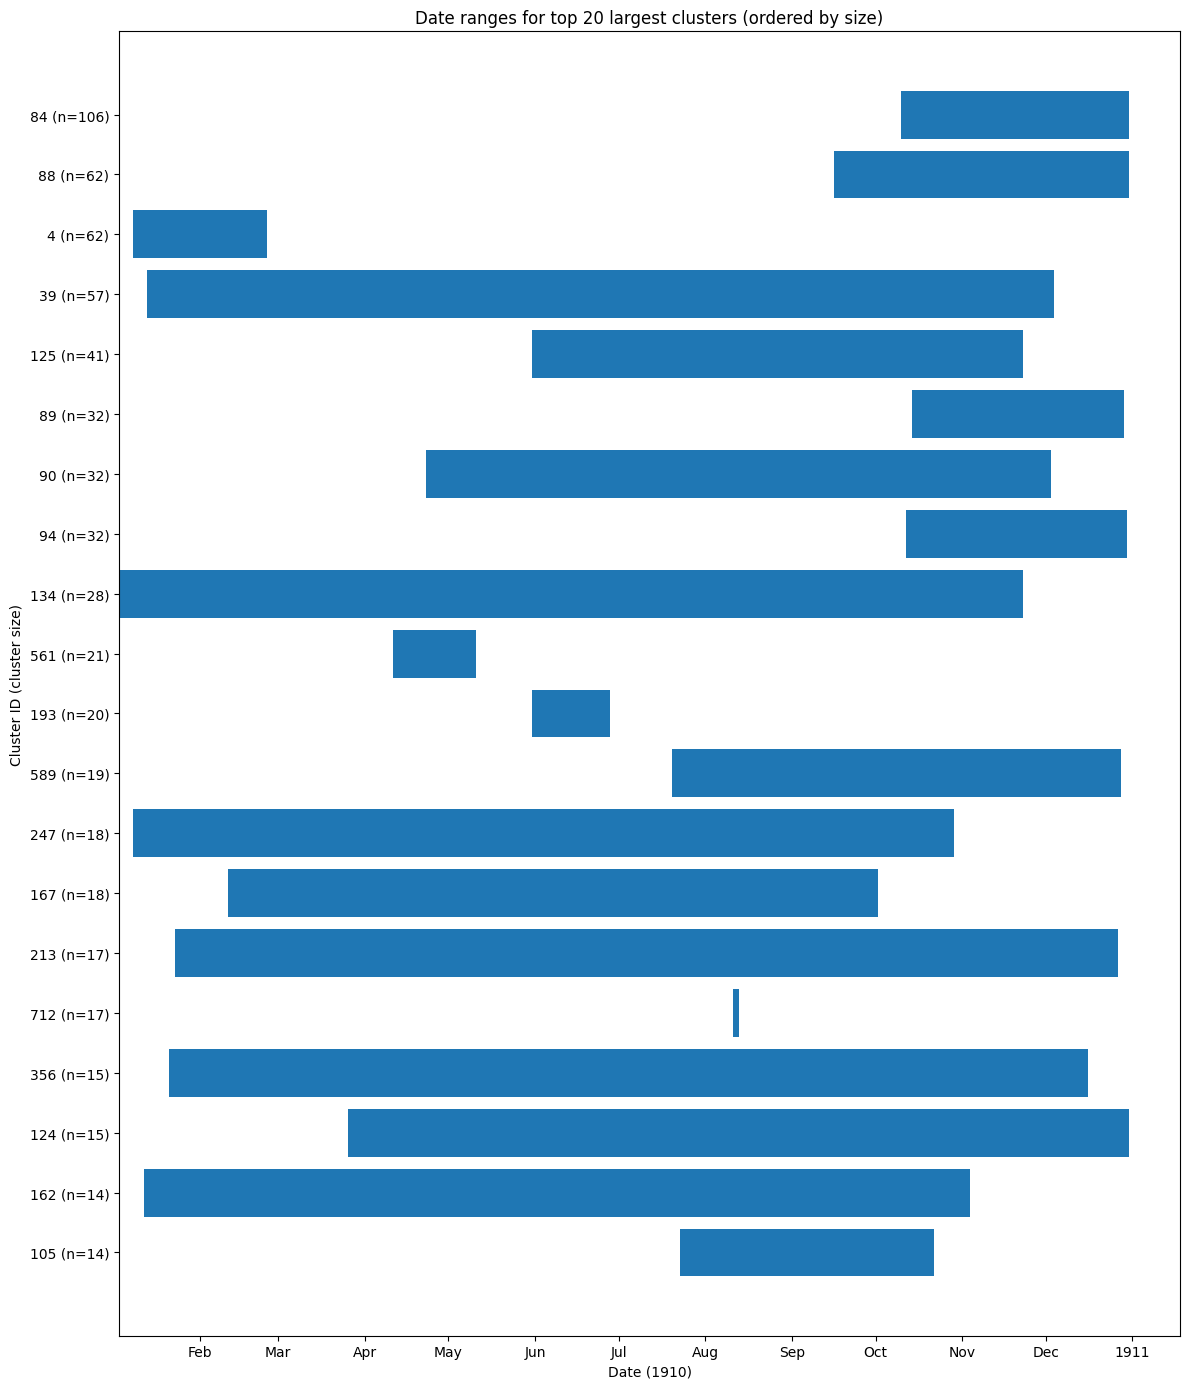

In [63]:
topN = 20

top_df = (
    cluster_dates_df
    .sort_values("n_images", ascending=False)
    .head(topN)
    .reset_index(drop=True)
)

y = range(len(top_df))

start = mdates.date2num(top_df["start_date"])
end = mdates.date2num(top_df["end_date"])
width = end - start

plt.figure(figsize=(12, 0.6 * len(top_df) + 2))
plt.barh(y, width, left=start)

labels = [
    f'{cid} (n={n})'
    for cid, n in zip(top_df["cluster_id"], top_df["n_images"])
]
plt.yticks(y, labels)

plt.gca().invert_yaxis() # largest cluster is at the top

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(
    mdates.ConciseDateFormatter(ax.xaxis.get_major_locator())
)

plt.xlabel("Date (1910)")
plt.ylabel("Cluster ID (cluster size)")
plt.title(f"Date ranges for top {topN} largest clusters (ordered by size)")
plt.tight_layout()
plt.show()

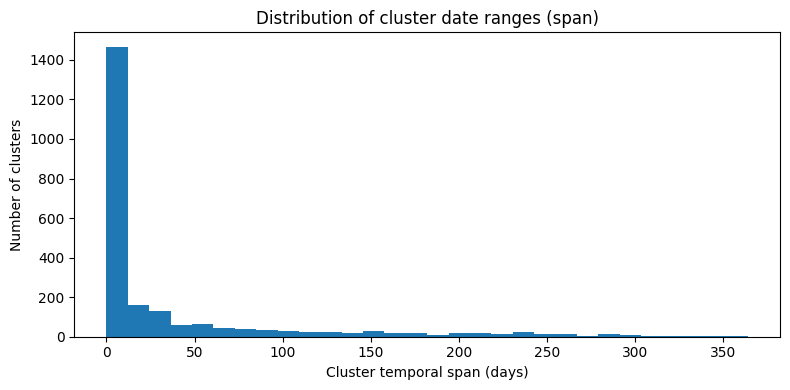

In [67]:
plt.figure(figsize=(8, 4))
plt.hist(cluster_dates_df["span_days"], bins=30)
plt.xlabel("Cluster temporal span (days)")
plt.ylabel("Number of clusters")
plt.title("Distribution of cluster date ranges (span)")
plt.tight_layout()
plt.show()